# 📉 Customer Churn Prediction

---
**Dataset:** Kaggle — Telco Customer Churn  
**Model:** Logistic Regression  
**Evaluation Metric:** ROC-AUC  

---

## 🎯 Problem Statement

Customer churn — when a subscriber cancels their service — is one of the costliest problems in the telecom industry. Acquiring a new customer costs 5–25× more than retaining an existing one. This project builds a **binary classification model** to predict whether a telecom customer will churn, enabling proactive retention strategies.

**Business Question:** *Given a customer's demographics, service plan, and billing behavior, how likely are they to leave in the next period?*

---

## 📋 Project Structure

| # | Section | Description |
|---|---|---|
| 1 | Setup & Data Loading | Import libraries, load train/test datasets |
| 2 | Exploratory Data Analysis | Distributions, class imbalance, key patterns |
| 3 | Data Cleaning & Encoding | Handle categoricals, encode for ML |
| 4 | Feature Engineering | 4 domain-informed features |
| 5 | Model Training | Logistic Regression with ROC-AUC evaluation |
| 6 | Results & Business Insights | Model performance and actionable findings |

## 1. 📦 Setup & Library Imports

**Libraries used:**
- `pandas` / `numpy` — data manipulation and numerical operations
- `matplotlib` / `seaborn` — visualization
- `scikit-learn` — preprocessing, models, and evaluation metrics
- `xgboost` — gradient boosted trees (available for future extension)

Warnings are suppressed to keep output clean.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## 2. 📂 Data Loading

Loading the Kaggle-provided train and test CSVs. The training set contains the target column `Churn`; the test set is used for final submission predictions.

| File | Shape | Notes |
|---|---|---|
| `train.csv` | 594,194 × 21 | Includes `Churn` target |
| `test.csv` | 254,655 × 20 | No target column |

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print('Train shape:', train.shape)
print('Test shape: ', test.shape)

Train shape: (594194, 21)
Test shape:  (254655, 20)


In [3]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
print('Data Types')
print(train.dtypes)

print('\nMissing Values')
print(train.isnull().sum())

print('\nBasic Statistics')
train.describe().round(2)

Data Types
id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing Values
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling   

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.00,594194.00,594194.00,594194.00,594194.00
mean,297096.50,0.11,36.58,65.87,2494.38
std,171529.18,0.32,25.06,31.07,2353.92
min,0.00,0.00,1.00,18.25,18.80
25%,148548.25,0.00,12.00,29.90,639.65
50%,297096.50,0.00,35.00,74.10,1433.65
75%,445644.75,0.00,62.00,90.80,4263.80
max,594193.00,1.00,72.00,118.75,8684.80


In [5]:
print(train['Churn'].value_counts())
print()
print(train['Churn'].value_counts(normalize=True) * 100)

Churn
No     460377
Yes    133817
Name: count, dtype: int64

Churn
No     77.479241
Yes    22.520759
Name: proportion, dtype: float64


In [6]:
train['Churn'] = (train['Churn'] == 'Yes').astype(int)

print(train['Churn'].value_counts())

Churn
0    460377
1    133817
Name: count, dtype: int64


## 3. 🔍 Exploratory Data Analysis (EDA)

Before modeling, we analyze the data to understand which features drive churn. This section investigates four key areas:

1. **Class distribution** — how balanced is the churn target?
2. **Contract type** — does commitment level predict churn?
3. **Tenure** — when in the customer lifecycle does churn happen?
4. **Monthly charges** — do higher-paying customers leave more?

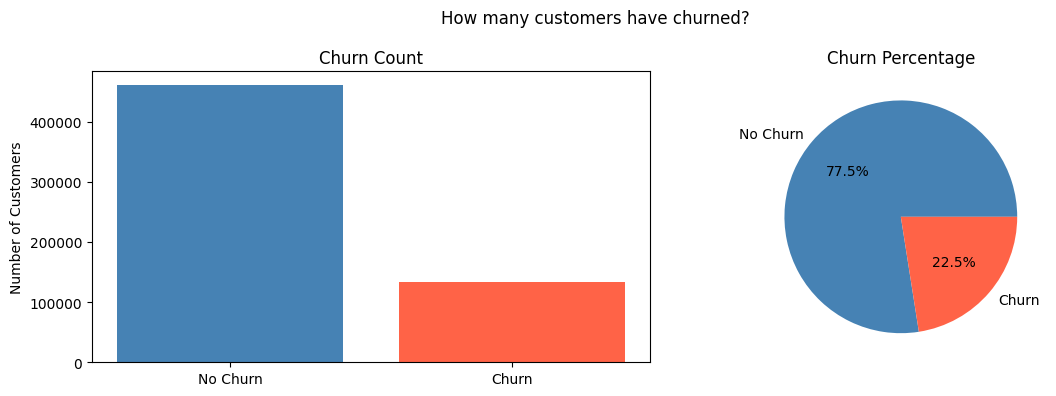

In [7]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
churn_counts = train['Churn'].value_counts()

#Bar Chart
axes[0].bar(['No Churn','Churn'],
            churn_counts.values,
           color=['steelblue','tomato'])
axes[0].set_title("Churn Count")
axes[0].set_ylabel("Number of Customers")

#Pie Chart
axes[1].pie(churn_counts.values,
            labels=['No Churn', 'Churn'],
            autopct='%1.1f%%',
            colors=['steelblue', 'tomato'])
axes[1].set_title('Churn Percentage')

plt.suptitle("How many customers have churned?")
plt.tight_layout()
plt.show()

Contract
Month-to-month    42.054343
One year           5.762787
Two year           0.998165
Name: Churn, dtype: float64



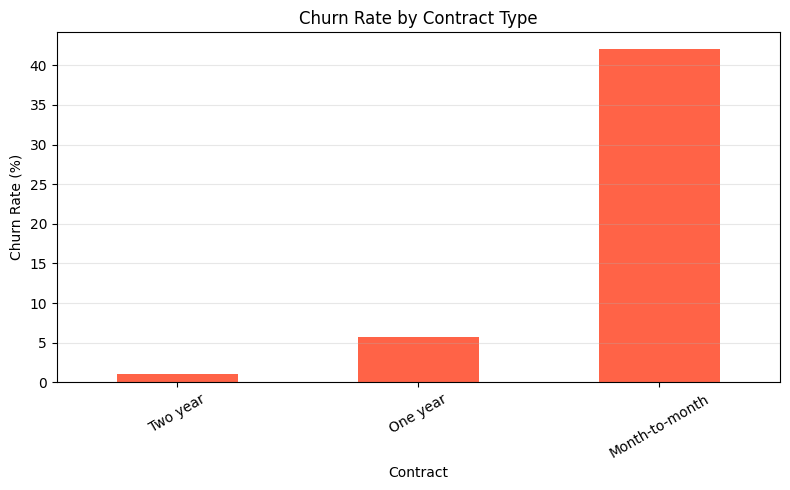

In [8]:
churn_by_contract = train.groupby('Contract')['Churn'].mean() * 100

print(churn_by_contract)
print()

churn_by_contract.sort_values().plot(kind='bar', color='tomato', figsize=(8, 5))
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

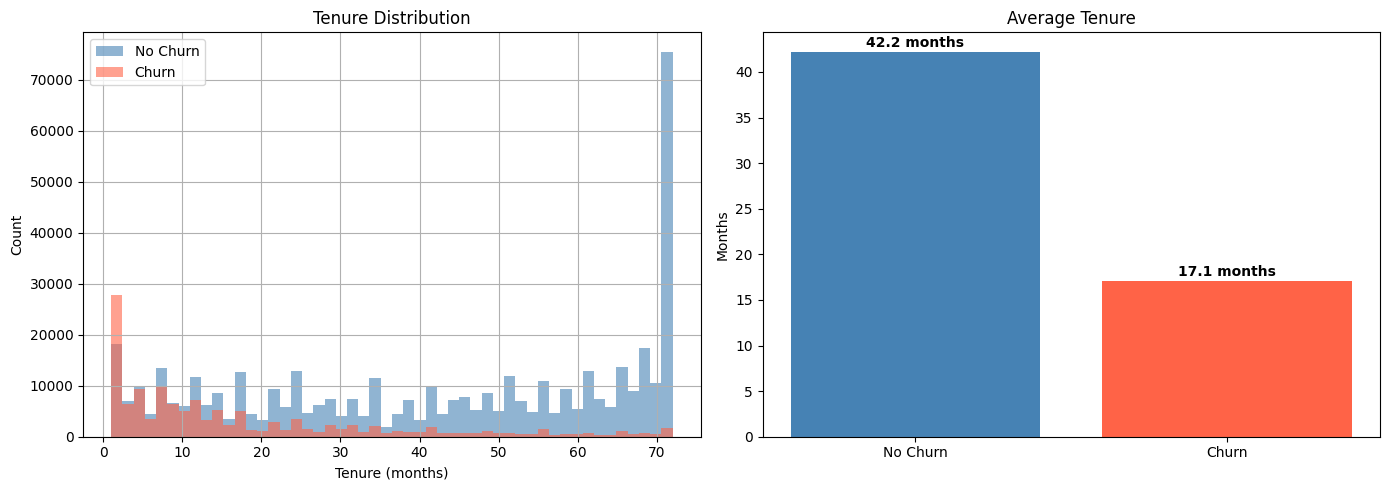

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train[train['Churn'] == 0]['tenure'].hist(
    bins=50, ax=axes[0], alpha=0.6, color='steelblue', label='No Churn'
)
train[train['Churn'] == 1]['tenure'].hist(
    bins=50, ax=axes[0], alpha=0.6, color='tomato', label='Churn'
)
axes[0].set_title('Tenure Distribution')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

avg_tenure = train.groupby('Churn')['tenure'].mean()
axes[1].bar(['No Churn', 'Churn'], avg_tenure.values, color=['steelblue', 'tomato'])
axes[1].set_title('Average Tenure')
axes[1].set_ylabel('Months')
for i, v in enumerate(avg_tenure.values):
    axes[1].text(i, v + 0.5, f'{v:.1f} months', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

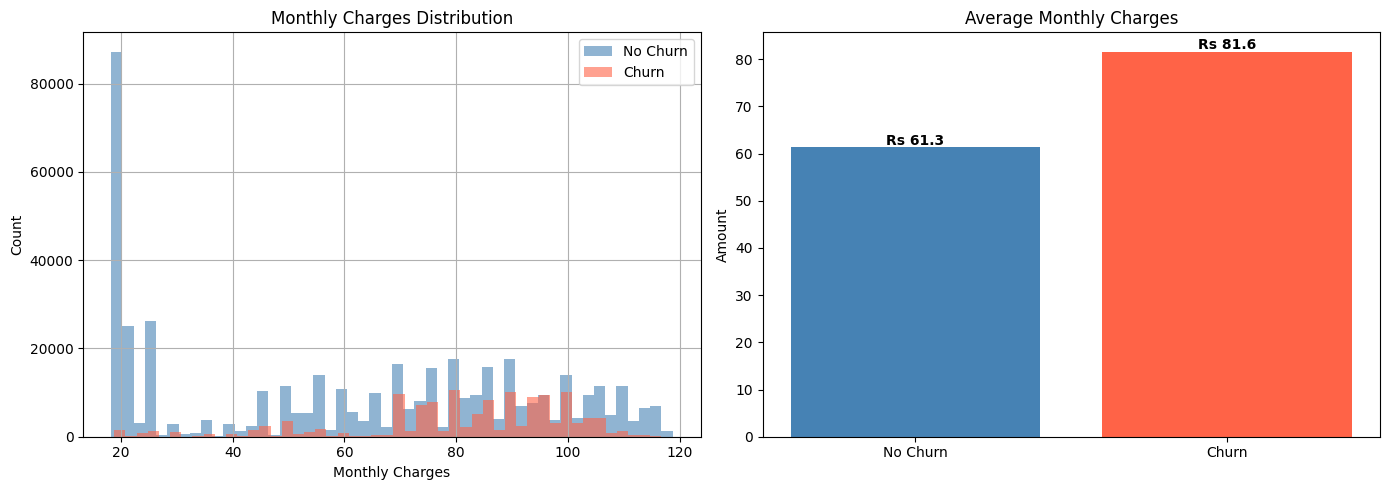

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train[train['Churn'] == 0]['MonthlyCharges'].hist(
    bins=50, ax=axes[0], alpha=0.6, color='steelblue', label='No Churn'
)
train[train['Churn'] == 1]['MonthlyCharges'].hist(
    bins=50, ax=axes[0], alpha=0.6, color='tomato', label='Churn'
)
axes[0].set_title('Monthly Charges Distribution')
axes[0].set_xlabel('Monthly Charges')
axes[0].set_ylabel('Count')
axes[0].legend()

avg_charges = train.groupby('Churn')['MonthlyCharges'].mean()
axes[1].bar(['No Churn', 'Churn'], avg_charges.values, color=['steelblue', 'tomato'])
axes[1].set_title('Average Monthly Charges')
axes[1].set_ylabel('Amount')
for i, v in enumerate(avg_charges.values):
    axes[1].text(i, v + 0.5, f'Rs {v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Customer Churn EDA — Key Findings
## Kaggle Playground Series S6E3

---

## Dataset Overview

| Property | Value |
|---|---|
| Training rows | 594,194 |
| Test rows | 254,655 |
| Features | 20 |
| Target | Churn (Yes / No) |

---

## Finding 1 — Class Imbalance

| Class | Count | Percentage |
|---|---|---|
| No Churn (0) | 460,377 | 77.5% |
| Churn (1) | 133,817 | 22.5% |

**Implication:** The dataset is imbalanced — 3 out of every 4 customers stayed. A model that predicts "No Churn" for everyone would be 77.5% accurate but completely useless. This is why we use ROC-AUC as our metric instead of accuracy, and `scale_pos_weight` in XGBoost to pay extra attention to churners.

---

## Finding 2 — Contract Type

| Contract | Churn Rate |
|---|---|
| Month-to-month | 42.1% |
| One year | 5.8% |
| Two year | 1.0% |

**Insight:** Contract type is the strongest predictor of churn. Month-to-month customers can leave anytime with zero friction — no cancellation fees, no commitment. Two year contract customers are almost completely locked in.

---

## Finding 3 — Tenure

| Group | Average Tenure |
|---|---|
| No Churn | 42.2 months |
| Churn | 17.1 months |

**Insight:** Customers who churn leave early — on average after just 17 months. There is a large spike in churn at tenure = 1 month, meaning many customers leave within their very first month. Customers who survive past 6 months are increasingly likely to stay long term.

---

## Finding 4 — Monthly Charges

| Group | Average Monthly Charges |
|---|---|
| No Churn | Rs 61.3 |
| Churn | Rs 81.6 |

**Insight:** Customers who churn pay more on average. This is likely because higher charges correlate with Fiber optic internet, which itself has a higher churn rate. Customers on cheap basic plans (around Rs 20/month) almost never churn.

---

## Summary Table

| Factor | Finding |
|---|---|
| Contract type | Month-to-month = 42% churn vs Two year = 1% |
| Tenure | Churners leave at avg 17 months vs stayers at 42 months |
| Monthly Charges | Churners pay Rs 81 vs Rs 61 for stayers |
| Class balance | 77.5% stay, 22.5% churn — imbalanced dataset |

---

## 4. 🧹 Data Cleaning & Encoding

**Goal:** Convert all categorical features to numeric format so they can be fed into ML models.

**Approach:** `LabelEncoder` from scikit-learn
- Fit on **train** labels only → transform both train and test
- This prevents **data leakage** from test set into encoding mappings

| Encoding Method | Suitable For |
|---|---|
| `LabelEncoder` (used here) | Tree-based models (Random Forest, XGBoost) |
| `OneHotEncoder` | Linear models (Logistic Regression) — future improvement |

In [11]:
cat_cols = train.select_dtypes(include="object").columns.tolist()
print(cat_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
le = LabelEncoder()
for col in cat_cols:
    le.fit(train[col])
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,1,29,1,0,0,2,...,2,2,0,0,1,1,3,60.10,1653.85,0
1,1,1,0,1,1,58,1,0,0,2,...,0,2,2,0,2,0,1,69.50,3778.20,0
2,2,1,0,1,0,58,1,2,1,0,...,0,0,2,2,0,1,2,100.40,5841.35,0
3,3,0,0,0,0,1,1,0,1,0,...,0,0,0,0,0,1,2,69.70,70.70,1
4,4,0,0,0,0,1,1,0,1,0,...,0,0,0,0,0,1,2,70.45,70.45,1


In [13]:
print(train.dtypes)

id                    int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


## 5. ⚙️ Feature Engineering

Raw features alone don't capture the full customer story. We engineer **4 domain-informed features** to improve model signal quality:

| New Feature | Formula | Business Rationale |
|---|---|---|
| `IsNewCustomer` | tenure ≤ 6 → 1 else 0 | New customers have the highest early-churn risk |
| `TotalServices` | Sum of 8 service binary flags | Customers using more services are more embedded in the ecosystem |
| `ChargesPerTenure` | MonthlyCharges / (tenure + 1) | Normalized spend — high for new customers paying full price |
| `ChargesPerService` | MonthlyCharges / (TotalServices + 1) | Effective cost per service — high = potentially overpriced |

> The `+1` smoothing prevents division-by-zero errors for customers with `tenure = 0` or zero services.

In [14]:
def add_features(df):
    df = df.copy()

    # 1. Is the customer new?
    df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

    # 2. Total number of services the customer uses
    service_cols = [
        'PhoneService', 'MultipleLines', 'OnlineSecurity',
        'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies'
    ]
    df['TotalServices'] = df[service_cols].sum(axis=1)

    # 3. Monthly charges per month of tenure
    df['ChargesPerTenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

    # 4. Monthly charges per service
    df['ChargesPerService'] = df['MonthlyCharges'] / (df['TotalServices'] + 1)

    return df

train = add_features(train)
test  = add_features(test)

print('New train shape:', train.shape)

New train shape: (594194, 25)


### 5.1 Train / Validation Split

We split the training data **80/20** using **stratified sampling** to preserve the ~22.5% churn ratio in both splits.

| Split | Rows | Purpose |
|---|---|---|
| `X_train` | 475,355 | Model training |
| `X_test` | 118,839 | Held-out validation — never seen during training |

> `stratify=y` ensures churn proportion is consistent across both splits, preventing the model from training on a skewed distribution.

In [15]:
X = train.drop(columns = ['id','Churn'])
y = train['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

X_train: (475355, 23)
X_test:  (118839, 23)


## 6. 🤖 Model Training & Evaluation

We train a **Logistic Regression** classifier and evaluate it using **ROC-AUC** as our primary metric.

> **Why ROC-AUC over Accuracy?**  
> With 77/23 class imbalance, a model that always predicts 'No Churn' scores 77% accuracy but is worthless. ROC-AUC measures ranking quality — how well the model separates churners from non-churners — regardless of threshold.

### 6.1 Logistic Regression

Logistic Regression models the log-odds of churn as a linear combination of features, outputting well-calibrated probabilities ideal for ranking and thresholding.

**Why Logistic Regression?**
- Interpretable — coefficients map directly to feature impact
- Fast to train even on 475K rows
- Strong probabilistic output for retention scoring

> `max_iter=1000` — increased from default 100 to ensure convergence on large data.

In [16]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train,y_train)

lr_pred = lr.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(y_test,lr_pred)

print(f'Logistic Regression AUC: {lr_auc:.4f}')

Logistic Regression AUC: 0.9087


---

## 7. 📊 Results Summary

| Model | ROC-AUC |
|---|---|
| **Logistic Regression** | **0.9087** |

**AUC of 0.9087** means the model correctly ranks a random churner above a random non-churner ~91% of the time — strong performance for a linear model on a large, imbalanced dataset.

---

## 8. 💡 Business Insights & Recommendations

| Finding | Business Action |
|---|---|
| Month-to-month churn = 42% vs. two-year = 1% | Offer contract-upgrade incentives at the 3-month mark |
| New customers (≤6 months) are highest risk | Trigger proactive outreach campaign in first 6 months |
| Churners pay ~₹81/month vs. ₹61 for stayers | Bundle discounts for high-paying single-service customers |
| Fiber optic customers churn more than DSL | Investigate service quality issues in the Fiber tier |

---

## 9. 🚀 Potential Extensions

- **OneHotEncoding** — better encoding for Logistic Regression (avoids ordinal assumptions from LabelEncoder)
- **Regularization tuning** — experiment with `C` parameter (L1/L2 penalty strength)
- **SHAP values** — explain individual predictions for retention team use
- **Threshold tuning** — optimize precision/recall tradeoff for churn targeting
- **Cross-validation** — more robust AUC estimates via 5-fold CV
- **XGBoost / LightGBM** — benchmark against non-linear models